# 08-03-2026

## Database - I

### Agenda:
- What is a Database?

### What is a Database?

A database is used to store or manage product/project data. 

It is basically a software which helps in CRUD operations:

- Creation of Data
- Reading Data
- Updation of Data
- Deletion of Data

# 11-03-2026

## Database - I (Continued)

### Agenda:
- Why Database?
- Database v/s DBMS
- Structure of Database
    - Visual Representation
    - Naive Users
    - Storage Manager
    - Explaination of All the Components of the Structure of Database
- Types of Database
    - Relational Database in Depth
    - NoSQL Database in Depth
- Structure of RDBMS
    - Example of All Keys in RDBMS

### Why Database?

- To make searching efficient

- To get rid of Race Condition (multiple systems accessing the same data)

- To get rid of Data Corruption

- To have proper relationship maintained between data and systems

### Database v/s DBMS

A **database** is the data itself. A **DBMS** is the software that manages that data.

#### Database

An organized collection of related data, stored so it can be retrieved and updated. In the diagram, this is the bottom layer: the data files, indices, and data dictionary. A university database, for example, holds students, courses, enrollments, and grades.

#### DBMS

The software that sits between users and the database. It lets you define the structure, insert, query, and update data, control who can access what, and keep everything consistent and recoverable. In the diagram, this is the middle layer: the query processor and storage manager. Examples are MySQL, PostgreSQL, Oracle, and SQL Server.

#### Side by side

| | Database | DBMS |
|---|---|---|
| **What it is** | Collection of data | Software that manages the data |
| **Nature** | Passive (it just sits there) | Active (it does the work) |
| **Role** | Stores information | Defines, stores, retrieves, secures, and protects it |
| **Example** | Your company's customer records | PostgreSQL |
| **Can exist alone?** | Not usefully; you need something to access it | Yes, but empty, with nothing to manage |

#### Analogy

Think of a library. The **database** is the books on the shelves. The **DBMS** is the librarian and the cataloging system: they know where everything is, check whether you're allowed to borrow something, stop two people from taking the same copy, and keep the records straight.

#### Why it matters

Before DBMSs, applications stored data in plain files, and each program had to handle access, consistency, and concurrency itself. That led to duplicated data, inconsistent updates, and no protection against crashes. A DBMS centralizes all of that so applications don't have to.

Together, the DBMS plus the database (plus the applications using them) is often called a **database system**.

### Structure of Database

"Structure of a database system" can mean a few things, so here are the three views that usually come up in study material.

#### 1. Overall structure: users, DBMS, and database

```
        Users
  (end users, analysts, programmers, DBA)
            │
   Application programs / Queries (SQL)
            │
┌───────────▼────────────────────────┐
│  DBMS (Database Management System) │
│                                    │
│  Query Processor                   │
│   ├─ DDL interpreter               │
│   ├─ DML compiler                  │
│   ├─ Query optimizer               │
│   └─ Query execution engine        │
│                                    │
│  Storage Manager                   │
│   ├─ Authorization & integrity mgr │
│   ├─ Transaction manager           │
│   ├─ File manager                  │
│   └─ Buffer manager                │
└───────────┬────────────────────────┘
            │
┌───────────▼────────────────────────┐
│  Disk storage                      │
│   ├─ Data files (the actual data)  │
│   ├─ Indices                       │
│   └─ Data dictionary (metadata)    │
└────────────────────────────────────┘
```

**Query processor**
- **DDL interpreter**: processes schema definitions (`CREATE`, `ALTER`) and records them in the data dictionary.
- **DML compiler**: translates `SELECT`, `INSERT`, `UPDATE`, `DELETE` into a low-level execution plan.
- **Query optimizer**: picks the cheapest way to run the query (which index, which join order).
- **Execution engine**: runs the chosen plan.

**Storage manager**
- **Authorization and integrity manager**: checks permissions and enforces constraints.
- **Transaction manager**: ensures ACID properties and handles concurrency and crash recovery.
- **File manager**: manages disk space and the structures used to store data.
- **Buffer manager**: moves data between disk and main memory.

**Disk storage**
- **Data files**: the tables themselves.
- **Indices**: structures that speed up lookups.
- **Data dictionary**: metadata, meaning data about the data (table names, column types, constraints).

**Users** fall into four groups: naive users (use forms and apps), application programmers, sophisticated users such as analysts (write SQL directly), and the **DBA** (database administrator), who manages schema, security, backup, and performance.

#### 2. Three-level architecture (ANSI-SPARC)

This describes how the data is viewed, and it's the answer to the phrase "structure of database system" in many textbooks.

| Level | Also called | What it describes |
|---|---|---|
| **External** | View level | What each user or application sees (a customized subset of the data) |
| **Conceptual** | Logical level | The whole database: entities, relationships, constraints (the schema) |
| **Internal** | Physical level | How data is actually stored: files, indexes, storage formats |

The point of this design is **data independence**:
- **Logical independence**: you can change the conceptual schema without breaking user views.
- **Physical independence**: you can change storage details (say, add an index) without changing the conceptual schema.

#### 3. Application architecture (tiers)

- **1-tier**: the database and application on the same machine (e.g., a local SQLite file).
- **2-tier (client-server)**: the client application talks directly to the database server.
- **3-tier**: client (UI) → application/web server (business logic) → database server. This is the standard for web applications.

### Visual Representation

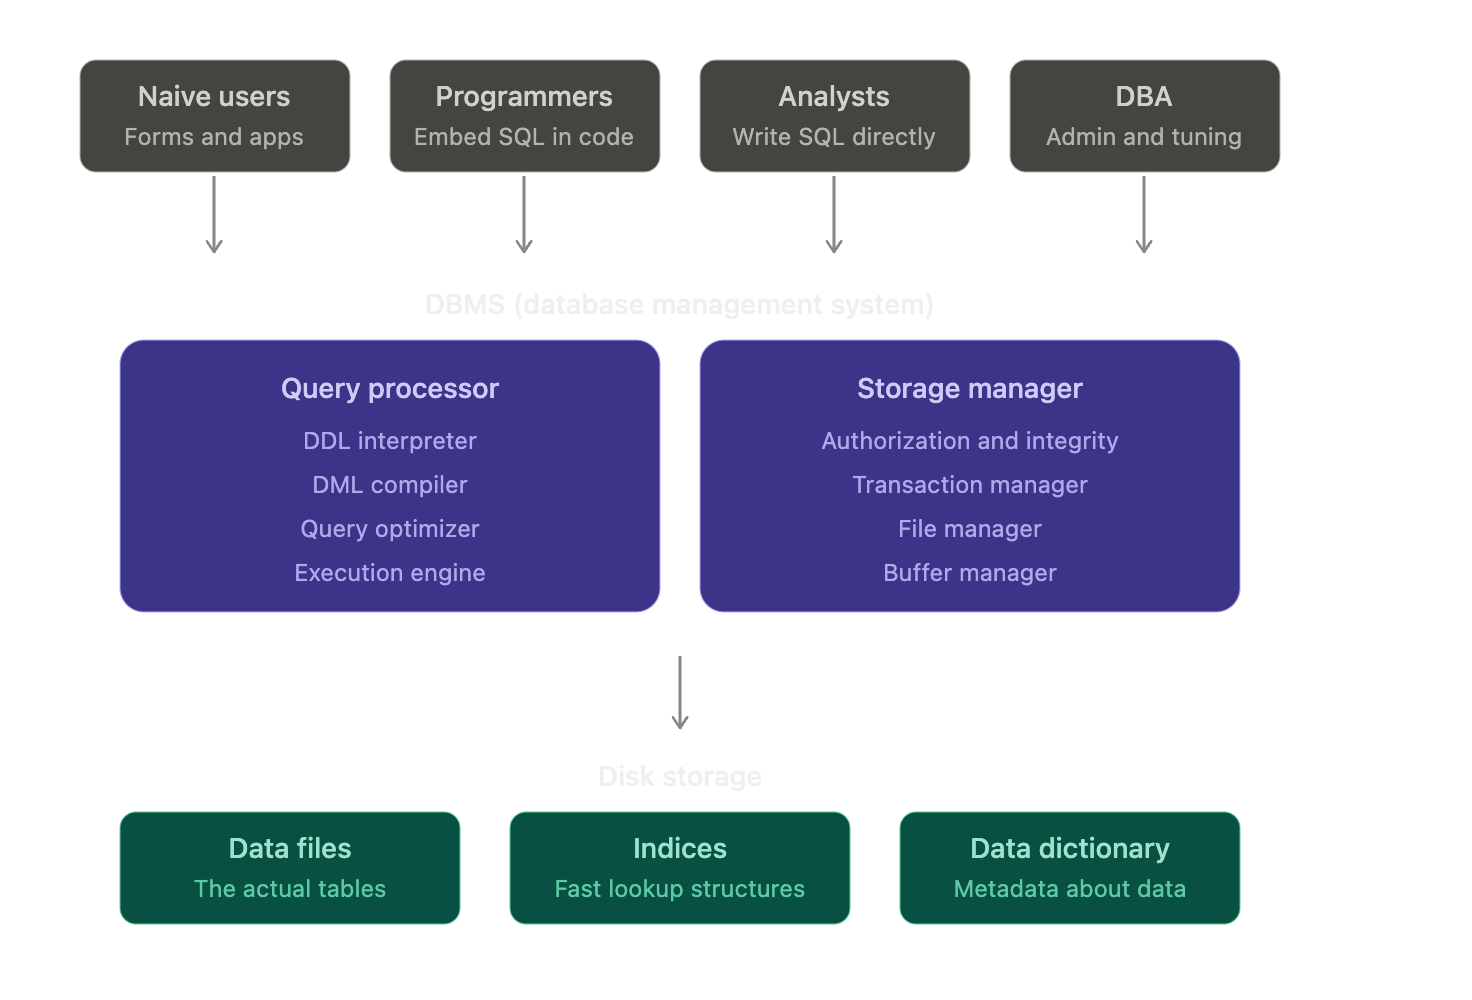

### Naive Users

Naive users (also called parametric users or end users) are the people who use a database through ready-made applications without knowing anything about the database itself. They don't write SQL, they don't know how the data is stored, and they usually don't realize a database is involved at all.

#### Key characteristics

- They interact through forms, menus, buttons, and mobile or web apps.
- They perform a fixed set of predefined operations, such as "check balance", "book ticket", or "place order".
- They need no technical knowledge of the database.
- They are usually the largest group of users in any system.

#### Examples

- A person transferring money through a banking app
- A customer booking a train or flight ticket on a reservation website
- A shopper adding items to a cart and paying on an e-commerce site
- A bank teller or cashier using a billing screen
- Someone checking their exam result on a university portal

In each case, the application converts the person's clicks and form entries into database queries behind the scenes, then displays the result in a friendly format.

#### How it works in the background

1. The user fills in a form, e.g. enters an account number and amount.
2. The application program (written by an application programmer) turns this into a query or transaction.
3. The DBMS runs it and returns the result.
4. The application shows the result, e.g. "Transfer successful".

#### Comparison with other user types

| User type | Skill needed | How they access data |
|---|---|---|
| **Naive users** | None | Predefined apps and forms |
| **Application programmers** | Programming and SQL | Write the apps that naive users use |
| **Sophisticated users** (analysts) | SQL and query tools | Write queries directly |
| **DBA** | Deep database knowledge | Manages schema, security, backup, performance |

#### Why they matter in the design

Because naive users can only perform the operations the application allows, the application acts as a controlled gateway. This improves security (they can't touch data they shouldn't) and protects data integrity, since they can't accidentally run a harmful query such as deleting a whole table.

### Storage Manager

The storage manager is the part of the DBMS that sits between the query processor and the disk. The query processor decides what to do (the execution plan), and the storage manager actually does it: it reads and writes data safely, quickly, and without letting users interfere with each other.

#### Its four components

**1. Authorization and integrity manager**
- Checks that the user is allowed to perform the operation (e.g., a user with read-only access can't `UPDATE`).
- Enforces integrity constraints such as primary keys, foreign keys, `NOT NULL`, and `CHECK` before data is written.

**2. Transaction manager**
- Makes sure transactions follow the ACID properties.
- **Concurrency control** (lock manager): when many users access the same data at once, it uses locks or isolation levels so they don't produce race conditions.
- **Recovery manager**: writes changes to a log first, so after a crash it can undo incomplete transactions and redo committed ones.

**3. File manager**
- Allocates space on disk and decides how tables are organized into files and pages (blocks).
- Keeps track of where each record physically lives.

**4. Buffer manager**
- Disk is slow and memory is fast, so it keeps frequently used pages in a memory cache called the buffer pool.
- Decides which pages to load and which to evict when memory is full (using policies like LRU).
- This is what makes a database fast in practice.

#### The data structures it manages on disk

- **Data files**: the tables themselves
- **Indices**: structures like B-trees that speed up lookups
- **Data dictionary**: metadata about tables, columns, and constraints

#### Example: what happens on a bank transfer

Suppose you run `UPDATE accounts SET balance = balance - 500 WHERE id = 7;`

1. The authorization manager checks you have permission to update `accounts`.
2. The transaction manager locks the row and writes the planned change to the log.
3. The buffer manager checks whether the page holding that row is already in memory. If not, the file manager fetches it from disk.
4. The change is made in memory, and the integrity manager verifies no constraint is violated (e.g., balance can't go negative).
5. On `COMMIT`, the log is flushed to disk so the change survives a crash, and the lock is released.

#### Why it matters

Almost every benefit of using a database from your earlier question comes from this component: efficient searching (indices and buffering), no race conditions (concurrency control), no data corruption (logging and recovery), and maintained relationships (integrity checks).

### Explaination of All the Components of the Database Structure

#### Users

- **Naive users:** People who never see SQL. They use forms and apps (a bank's ATM, an airline booking page), and the application runs predefined queries for them.
- **Programmers:** Developers who embed SQL inside application code (Java, Python, etc.), often through an API like JDBC. They build the apps naive users rely on.
- **Analysts:** People who write SQL directly, usually ad hoc queries for reporting or exploring data.
- **DBA (database administrator):** Has central control of the system. They design the schema, grant access, tune performance, and handle backup and recovery.

#### Query processor

Everything here deals with *what* the user asked for and *how* to get it.

- **DDL interpreter:** Processes schema definitions (`CREATE TABLE`, `ALTER`, `DROP`) and records the resulting metadata in the data dictionary.
- **DML compiler:** Translates data manipulation statements (`SELECT`, `INSERT`, `UPDATE`, `DELETE`) into a low-level evaluation plan the engine can run.
- **Query optimizer:** Picks the cheapest way to run a query. One query can be executed many ways (different join orders, using an index or scanning the table), and the optimizer estimates costs to choose one.
- **Execution engine:** Carries out the chosen plan step by step, requesting data from the storage manager and returning results.

#### Storage manager

This is the interface between the high-level queries and the raw data on disk.

- **Authorization and integrity:** Checks that a user has permission for the operation, and that the change doesn't violate constraints (primary keys, foreign keys, `NOT NULL`, etc.).
- **Transaction manager:** Makes sure the database stays correct despite concurrent users and crashes. It enforces the ACID properties (atomicity, consistency, isolation, durability) using concurrency control and recovery.
- **File manager:** Allocates space on disk and tracks how data is laid out in files.
- **Buffer manager:** Moves data between disk and main memory. Since disk is far slower than RAM, it keeps frequently used pages cached in memory.

#### Disk storage

- **Data files:** The actual tables and their rows, stored on disk.
- **Indices:** Auxiliary structures (like B+ trees or hash indexes) that let the system find rows quickly without scanning a whole table, the same way a book's index saves you from reading every page.
- **Data dictionary:** Also called the system catalog. It stores metadata: table names, column types, constraints, index definitions, and user permissions. The DDL interpreter writes to it, and the query processor reads it constantly.

#### How a query flows

An analyst's `SELECT` goes to the DML compiler, then the optimizer picks a plan, and the execution engine runs it. The engine asks the storage manager for data, which checks permissions, uses the buffer manager to pull pages from the data files (probably via an index), and returns the rows back up the chain.

### Types of Database

Databases can be classified in several ways. The most common is by **data model**.

#### By data model

**Relational (SQL)**
Data lives in tables of rows and columns, linked by keys, and is queried with SQL. It has a fixed schema and strong ACID guarantees. It's the model the diagram you shared is built around.
*Examples: MySQL, PostgreSQL, Oracle, SQL Server.*
*Best for: banking, ERP, anything with structured data and strict consistency.*

**NoSQL**
An umbrella term for non-relational databases, which usually have flexible schemas and scale horizontally. It has four main subtypes:

- **Document:** Stores JSON-like documents. Each record can have a different structure. *MongoDB, CouchDB.*
- **Key-value:** A giant dictionary that maps a key to a value. Very fast for simple lookups. *Redis, DynamoDB.*
- **Column-family (wide-column):** Stores data by column groups, which suits huge datasets spread across many machines. *Cassandra, HBase.*
- **Graph:** Stores nodes and relationships, and is built for traversing connections. *Neo4j, Amazon Neptune.*

**Hierarchical**
Data is organized as a tree, with each record having one parent. It's fast for parent-child access but rigid. *IBM IMS.* It's mostly legacy today.

**Network**
Like hierarchical, but a record can have multiple parents, so it forms a graph. Also mostly legacy. *IDMS.*

**Object-oriented**
Stores data as objects, the way object-oriented programming languages represent them, with no translation layer. *db4o, ObjectDB.*

#### By architecture or purpose

- **Centralized:** All data sits on one server or site.
- **Distributed:** Data is spread across multiple machines or locations, for scalability and fault tolerance.
- **Cloud:** Runs as a managed service. *Amazon RDS, Google Cloud Spanner, Azure SQL.*
- **In-memory:** Keeps data in RAM for very low latency. *Redis, SAP HANA.*
- **Time-series:** Optimized for timestamped data like sensor readings or metrics. *InfluxDB, TimescaleDB.*
- **Data warehouse:** Built for analytics over large historical data, not day-to-day transactions (OLAP rather than OLTP). *Snowflake, BigQuery, Redshift.*
- **NewSQL:** Aims to combine SQL and ACID guarantees with NoSQL-style horizontal scaling. *CockroachDB, Google Spanner.*

#### Quick comparison

| Type | Structure | Schema | Typical strength |
|---|---|---|---|
| Relational | Tables | Fixed | Consistency, complex queries |
| Document | JSON documents | Flexible | Evolving app data |
| Key-value | Key → value | None | Speed, caching |
| Column-family | Column groups | Semi-flexible | Massive write-heavy data |
| Graph | Nodes and edges | Flexible | Relationship-heavy queries |

Many real systems use more than one type. An app might keep orders in PostgreSQL, sessions in Redis, and recommendations in a graph database. This is called **polyglot persistence**.

### Relational databases in depth

**Structure:** Data is stored in **tables** (relations). Each row is a record and each column is an attribute with a defined type. Tables link through keys:
- **Primary key:** uniquely identifies a row.
- **Foreign key:** references another table's primary key, which is how relationships are expressed.

**Normalization:** You split data into separate tables to avoid redundancy. A customer's address is stored once in `customers`, not repeated on every order. You then reassemble the data with **joins**.

**Schema-on-write:** You define the structure first (the DDL interpreter in your diagram), and the database rejects data that doesn't fit.

**ACID transactions:**
- **Atomicity:** all steps of a transaction happen, or none do.
- **Consistency:** the database moves from one valid state to another.
- **Isolation:** concurrent transactions don't interfere with each other.
- **Durability:** once committed, data survives crashes.

The classic example is a bank transfer: debit one account and credit another, and either both happen or neither does.

**Strengths:** powerful ad hoc queries (SQL and joins), strong data integrity, mature tooling, and a standard language.
**Weaknesses:** schema changes can be painful on large tables, and scaling across many machines is harder because joins and transactions get expensive when data is spread out.

### NoSQL databases in depth

**Schema flexibility:** Most NoSQL systems use **schema-on-read**. You can store records with different fields, and the application interprets them.

**Denormalization:** Instead of joining at query time, you often store related data together. A document database might keep an order with its line items and shipping address nested in one document. Reads become fast because one lookup fetches everything, but updates are harder because the same data may live in several places.

**Horizontal scaling:** NoSQL systems are usually designed to scale **out** (adding more commodity machines and splitting data across them, called **sharding**) rather than **up** (buying a bigger server).

**BASE instead of ACID:** Many NoSQL systems trade strict consistency for availability and speed:
- **Basically Available:** the system keeps responding even during partial failures.
- **Soft state:** data may be temporarily inconsistent across nodes.
- **Eventually consistent:** given time, all replicas converge to the same value.

**The CAP theorem** explains why. In a distributed system, when a network partition happens, you can guarantee only one of these two:
- **Consistency:** every read sees the latest write.
- **Availability:** every request gets a response.

(Partition tolerance is effectively mandatory in distributed systems.) Traditional relational systems favor consistency; many NoSQL systems favor availability. Note that some NoSQL databases, such as MongoDB, now support multi-document ACID transactions, so the line is blurrier than it used to be.

**Strengths:** flexible schemas, easy horizontal scaling, and high throughput for specific access patterns.
**Weaknesses:** weaker or no joins, less standardized query languages, and more consistency logic pushed onto the application.

### Side by side

| | Relational | NoSQL |
|---|---|---|
| **Data model** | Tables, rows, columns | Documents, key-value, columns, or graphs |
| **Schema** | Fixed, defined up front | Flexible, evolves easily |
| **Query language** | SQL (standardized) | Varies by database |
| **Relationships** | Joins across normalized tables | Embedded or denormalized data (graph DBs excepted) |
| **Consistency** | Strong (ACID) | Often eventual (BASE), varies |
| **Scaling** | Traditionally vertical | Designed for horizontal |
| **Best fit** | Structured, interrelated data | Large-scale, varied, or fast-changing data |

### When to choose which

**Choose relational when:**
- Your data is structured and has clear relationships (customers, orders, products).
- Correctness matters most, as in finance, inventory, and healthcare records.
- You need complex queries, reporting, or joins across many entities.
- Your requirements are still changing in how you *query* the data, since SQL is flexible for questions you didn't plan for.

**Choose NoSQL when:**
- The data shape varies or evolves rapidly (user-generated content, product catalogs with differing attributes).
- You need massive scale or write throughput across many servers.
- Your access patterns are simple and known in advance (fetch a user profile by ID).
- The data is naturally a graph (social networks, fraud rings), which suits a graph database.

**Matching the subtype to the need:**
- Caching or sessions: key-value (Redis)
- Flexible app data: document (MongoDB)
- Huge write-heavy logs or IoT data: column-family (Cassandra)
- Relationship traversal: graph (Neo4j)

### Common misconceptions

- **"NoSQL is faster."** Only for the access patterns it was designed around. A well-indexed relational database handles many workloads very well.
- **"NoSQL means no SQL."** It's usually read as "not only SQL," and some NoSQL systems offer SQL-like query languages.
- **"Relational can't scale."** It can, with replication, partitioning, and NewSQL systems, but it takes more effort.
- **"Pick one."** Most large systems combine both (polyglot persistence).

**A rule of thumb:** start with relational unless you have a specific reason not to. Its guarantees and flexibility cover most applications, and you can add NoSQL for the parts that need it.

### Structure of RDBMS

The core structure of an RDBMS has two sides: the **logical structure** (how data is organized) and the **components** that manage it (the architecture from your diagram).

#### Logical structure: the building blocks

**Relation (table):** A named collection of data about one kind of entity, such as `Student`.

**Tuple (row/record):** One instance of that entity, such as a single student.

**Attribute (column/field):** A property of the entity, such as `name` or `email`.

**Domain:** The set of allowed values for an attribute, such as integers, dates, or a set of valid grade letters.

Two related terms you'll see in exams:
- **Degree:** the number of columns in a table.
- **Cardinality:** the number of rows in a table.

**Schema vs instance:**
- The **schema** is the structure (table names, columns, types, constraints). It rarely changes.
- The **instance** is the data currently in the tables. It changes constantly.

#### Keys

Keys identify rows and link tables together.

| Key | Meaning |
|---|---|
| **Super key** | Any set of columns that uniquely identifies a row |
| **Candidate key** | A minimal super key (no column can be removed) |
| **Primary key** | The candidate key chosen as the main identifier; cannot be NULL |
| **Alternate key** | Candidate keys not chosen as primary |
| **Composite key** | A key made of two or more columns |
| **Foreign key** | A column that references another table's primary key |

#### Integrity constraints

These are the rules the DBMS enforces, which is the "authorization and integrity" job in the storage manager.

- **Domain constraint:** values must match the column's type or allowed range (`CHECK`, `NOT NULL`).
- **Entity integrity:** a primary key can't be NULL or duplicated.
- **Referential integrity:** a foreign key must match an existing primary key value (or be NULL). You can't enroll a student who doesn't exist.
- **Unique constraint:** no duplicate values in that column.

#### Relationships between tables

- **One-to-one:** one person has one passport.
- **One-to-many:** one department has many employees (the foreign key goes on the "many" side).
- **Many-to-many:** students and courses. This needs a **junction table** (like `Enrollment`) holding a foreign key to each side.

#### Properties of a relation

- Each cell holds a single atomic value (no lists inside a cell).
- Column names are unique within a table.
- Row order and column order don't matter.
- No two rows are identical.

#### Example

```sql
CREATE TABLE Department (
  dept_id   INT PRIMARY KEY,
  dept_name VARCHAR(50) NOT NULL UNIQUE
);

CREATE TABLE Student (
  student_id INT PRIMARY KEY,
  name       VARCHAR(100) NOT NULL,
  dept_id    INT,
  FOREIGN KEY (dept_id) REFERENCES Department(dept_id)
);
```

Here `Student` is a relation with three attributes (degree 3). `dept_id` is a foreign key, so every student must belong to a real department.

#### Supporting objects

Besides tables, an RDBMS typically holds:
- **Indexes:** speed up lookups (the "Indices" box in your diagram).
- **Views:** saved queries that behave like virtual tables.
- **Stored procedures and triggers:** logic stored inside the database.
- **The data dictionary (catalog):** metadata describing all of the above.

#### How this maps to your diagram

| Diagram component | Structural role |
|---|---|
| Data files | The tables (relations) and their rows |
| Indices | Indexes on chosen columns |
| Data dictionary | Schema definitions, keys, constraints, permissions |
| DDL interpreter | Creates and alters the structure |
| DML compiler / optimizer / execution engine | Queries and modifies the data |
| Authorization and integrity | Enforces the constraints above |
| Transaction manager | Keeps changes ACID |

### Example of All Keys

#### Example tables

**Student**

| student_id | roll_no | email | name | dept_id |
|---|---|---|---|---|
| 1 | CS101 | asha@uni.edu | Asha | 10 |
| 2 | CS102 | ravi@uni.edu | Ravi | 10 |
| 3 | EE101 | asha.k@uni.edu | Asha | 20 |

**Department**

| dept_id | dept_name |
|---|---|
| 10 | Computer Science |
| 20 | Electrical |

Note that `name` is *not* unique (two Ashas), but `student_id`, `roll_no`, and `email` are.

###### 1. Super key

Any set of columns that uniquely identifies every row, even if it includes unnecessary extra columns.

Valid super keys for Student:
- `{student_id}`
- `{roll_no}`
- `{email}`
- `{student_id, name}` (still unique, but `name` is redundant)
- `{roll_no, name, dept_id}`

Not a super key: `{name}` (two Ashas) or `{dept_id}` (two students in dept 10).

Any set that contains a unique column is a super key, so a table usually has many of them.

#### 2. Candidate key

A **minimal** super key: remove any column and it stops being unique.

- `{student_id}`, `{roll_no}`, and `{email}` are candidate keys, since each is unique on its own.
- `{student_id, name}` is **not** a candidate key, because you can drop `name` and it still works.

Candidate keys are the "possible choices" for the primary key.

#### 3. Primary key

The one candidate key you pick as the official row identifier. It can't be NULL and can't repeat. A table has exactly one primary key.

Here we choose `student_id`. It's short, stable, and never changes, which is why it beats `email` (people change emails).

#### 4. Alternate key

The candidate keys you *didn't* choose as primary. Here that's `roll_no` and `email`. They're usually enforced with `UNIQUE`.

#### 5. Unique key

A constraint that forbids duplicate values in a column but is not the primary key. A table can have many, and unlike a primary key it typically allows NULLs (how many NULLs varies by DBMS).

`email` is a unique key: two students can't share an email, but a student with no email yet is allowed.

#### 6. Composite key

A key made of **two or more columns** that together identify a row. Neither column alone is enough.

Consider an Enrollment table linking students to courses:

| student_id | course_id | grade |
|---|---|---|
| 1 | C1 | A |
| 1 | C2 | B |
| 2 | C1 | A |

`student_id` repeats and `course_id` repeats, but the pair `(student_id, course_id)` is unique. So the composite primary key is `(student_id, course_id)`.

#### 7. Foreign key

A column that references the primary key of another table (or the same table), creating a relationship and enforcing referential integrity.

- `Student.dept_id` references `Department.dept_id`. Inserting a student with `dept_id = 99` fails, because no such department exists.
- In Enrollment, `student_id` references Student and `course_id` references Course. Both are foreign keys and together form the composite primary key.

A foreign key can repeat (many students in dept 10) and can be NULL, unlike a primary key.

#### 8. Surrogate vs natural key

- **Natural key:** meaningful data that already exists, such as `email` or `roll_no`.
- **Surrogate key:** an artificial identifier with no business meaning, such as an auto-increment `student_id`.

Surrogate keys are popular because they never need to change, while natural keys sometimes do.

#### All in SQL

```sql
CREATE TABLE Department (
  dept_id   INT PRIMARY KEY,
  dept_name VARCHAR(50) NOT NULL UNIQUE
);

CREATE TABLE Student (
  student_id INT PRIMARY KEY,                 -- primary key
  roll_no    VARCHAR(10) NOT NULL UNIQUE,     -- alternate key
  email      VARCHAR(100) UNIQUE,             -- alternate key / unique key
  name       VARCHAR(100) NOT NULL,
  dept_id    INT,
  FOREIGN KEY (dept_id) REFERENCES Department(dept_id)   -- foreign key
);

CREATE TABLE Enrollment (
  student_id INT,
  course_id  VARCHAR(10),
  grade      CHAR(1),
  PRIMARY KEY (student_id, course_id),        -- composite key
  FOREIGN KEY (student_id) REFERENCES Student(student_id)
);
```

#### How they relate

```
Super keys (any unique set of columns)
  └── Candidate keys (minimal super keys)
        ├── Primary key (the one chosen)
        └── Alternate keys (the rest)
```

Foreign keys sit outside this hierarchy, since they point to *another* table's key.

#### Quick comparison

| Key | Unique? | NULL allowed? | How many per table? |
|---|---|---|---|
| Primary | Yes | No | Exactly one |
| Candidate | Yes | Depends on chosen use | Several |
| Alternate | Yes | Usually no | Several |
| Unique | Yes | Usually yes | Several |
| Composite | Yes (as a combination) | No, if primary | Can be primary or unique |
| Foreign | No | Yes | Several |